5. 아래의 Titanic 데이터를 활용하여 다음 조건에 따라 전처리 후 결과값을 구하시오.

[조건]
1. fare 컬럼에서 값이 가장 작은 16개 값을 해당 값 중 가장 큰 값으로 일괄 변환하시오.
2. 전처리 후 전체 데이터에서 age가 30 이하인 승객만 필터링하시오.
3. 필터링된 승객들의 fare 평균값을 구하시오.

In [49]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 데이터
titanic = sns.load_dataset("titanic")

In [6]:
# 가장 작은 16명의 fare 값 중 가장 큰 값
min_fare = titanic["fare"].sort_values().values[15]
min_fare

np.float64(4.0125)

In [10]:
# 16명의 fare 값을 가장 큰 값으로 변환
titanic.loc[titanic["fare"] <= min_fare, "fare"] = min_fare

In [11]:
titanic["fare"].sort_values().head()

271    4.0125
597    4.0125
302    4.0125
633    4.0125
277    4.0125
Name: fare, dtype: float64

In [13]:
# age값이 30이하인 승객에서의 fare 변수 값의 평균
titanic.loc[titanic["age"] <= 30, "fare"].mean()

np.float64(29.003106356968217)

6. Telco-Customer-Churn.csv에서 MonthlyCharges 컬럼의 이상치를 파악하여 이상치의 총합을 구하는 코드와 그 값을 답안으로 작성하시오

이때, 이상치는 평균에서 표준편차의 1.5배 보다 더 멀리 떨어진 데이터들로 정의한다

In [14]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# MonthlyCharges 컬럼 평균
m = df["MonthlyCharges"].mean()
m

np.float64(64.76169246059918)

In [19]:
# MonthlyCharges 컬럼 표준편차
s = df["MonthlyCharges"].std()
s

30.09004709767854

In [22]:
df.loc[(df["MonthlyCharges"] > (m + 1.5 * s)) | (df["MonthlyCharges"] < (m - 1.5 * s)), "MonthlyCharges"].sum()

np.float64(31707.35)

7. wine_전처리.csv 데이터에서 결측값을 가진 모든 행을 제거한 후, 데이터를 처음부터 순서대로 50%를 추출하여 alcohol 변수의 3사분위수를 산출하는 코드와 그 값을 답안으로 작성하시오

In [23]:
df = pd.read_csv("wine_전처리.csv")

In [24]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [25]:
df.shape

(178, 13)

In [26]:
df.isnull().sum()

alcohol                          0
malic_acid                       0
ash                              0
alcalinity_of_ash                0
magnesium                       16
total_phenols                   16
flavanoids                       0
nonflavanoid_phenols             0
proanthocyanins                  0
color_intensity                  0
hue                              0
od280/od315_of_diluted_wines     0
proline                          0
dtype: int64

In [27]:
# 결측값을 가진 모든 행 제거
df_cleaned = df.dropna(axis = 0)

In [28]:
df_cleaned.shape

(162, 13)

In [29]:
df_cleaned.shape[0] * 0.5

81.0

In [32]:
# 처음부터 순서대로 50%를 추출
df_sampled = df_cleaned.iloc[:int(df_cleaned.shape[0] * 0.5)]

In [34]:
df_sampled.shape

(81, 13)

In [36]:
# alcohol 변수의 3사분위수
df_sampled["alcohol"].describe()["75%"]

np.float64(13.83)

In [37]:
df_sampled["alcohol"].quantile(0.75)

np.float64(13.83)

8.  주요발생국가주간동향(4월2째주).csv 데이터에서 4월07일 컬럼의 값이 해당 컬럼의 평균 이상인 데이터의 행 수를 산출하는 코드와 그 값을 답안으로 작성하시오

In [38]:
df = pd.read_csv("주요발생국가주간동향(4월2째주).csv")

In [39]:
df.head()

,국가,4월06일,4월07일,4월08일,4월09일,4월10일,4월11일,4월12일
0,미국,335524,364723,387547,424945,461437,495535,524903
1,스페인,130709,135032,140510,146690,152446,157022,161852
2,이탈리아,128948,132547,135586,139422,143626,147577,152271
3,독일,100024,102453,107591,112113,118181,122171,124908
4,프랑스,70478,74390,78167,82048,86334,90276,93790


In [43]:
df.loc[df["4월07일"] >= df["4월07일"].mean()].shape[0]

3

9.  titanic 데이터셋에서 age가 18보다 크고 fare가 50보다 작은 승객의 수를 구하는 코드와 그 값을 답안으로 작성하시오

In [44]:
titanic = sns.load_dataset("titanic")

In [46]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [48]:
titanic.loc[(titanic["age"] > 18) & (titanic["fare"] < 50)].shape[0]

453

10. 펭귄 데이터셋에서 펭귄들의 부리 길이 분포를 적절한 그래프로 나타내시오

In [50]:
df = sns.load_dataset("penguins")

In [51]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


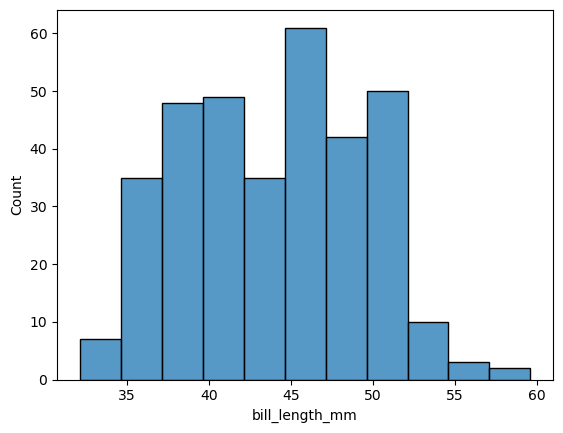

In [52]:
sns.histplot(df["bill_length_mm"])
plt.show()

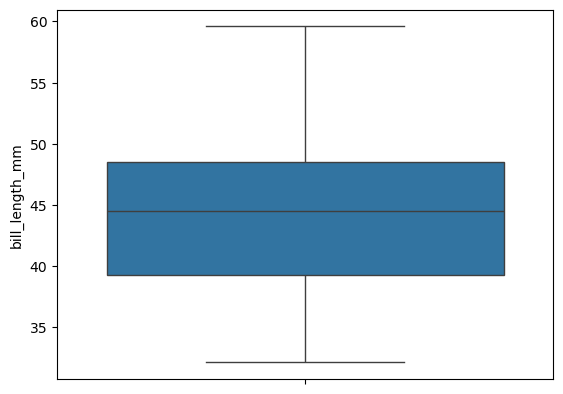

In [53]:
sns.boxplot(data = df, y = "bill_length_mm")
plt.show()

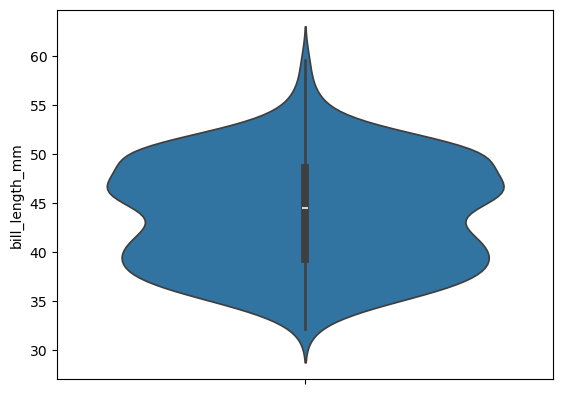

In [54]:
sns.violinplot(data = df, y = "bill_length_mm")
plt.show()

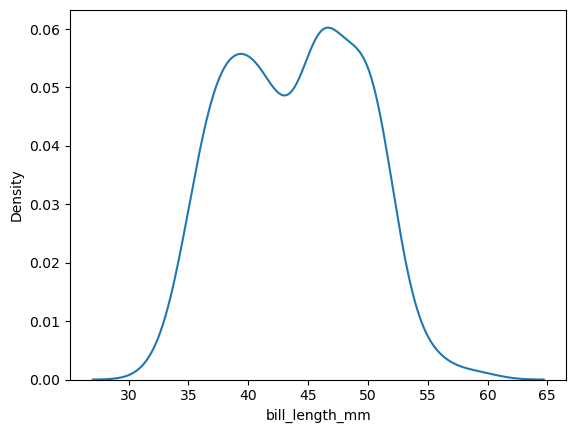

In [56]:
sns.kdeplot(data = df, x = "bill_length_mm")
plt.show()

11. 펭귄 데이터셋에서 종(species)에 따른 펭귄의 평균 부리 길이(bill_length_mm)를 적절한 그래프로 나타내시오

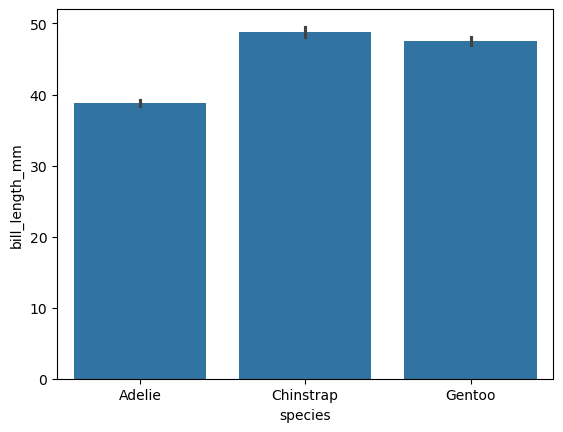

In [57]:
sns.barplot(x = "species", y = "bill_length_mm", data = df)
plt.show()

In [59]:
mean_bill = df.groupby("species")["bill_length_mm"].mean()
mean_bill

species
Adelie       38.791391
Chinstrap    48.833824
Gentoo       47.504878
Name: bill_length_mm, dtype: float64

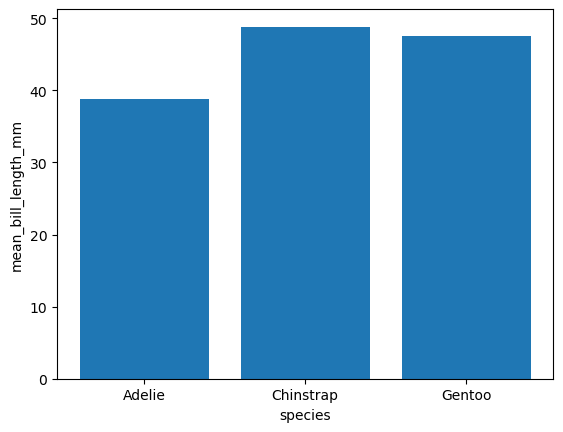

In [60]:
plt.figure()
plt.bar(mean_bill.index, mean_bill)

plt.xlabel("species")
plt.ylabel("mean_bill_length_mm")

plt.show()

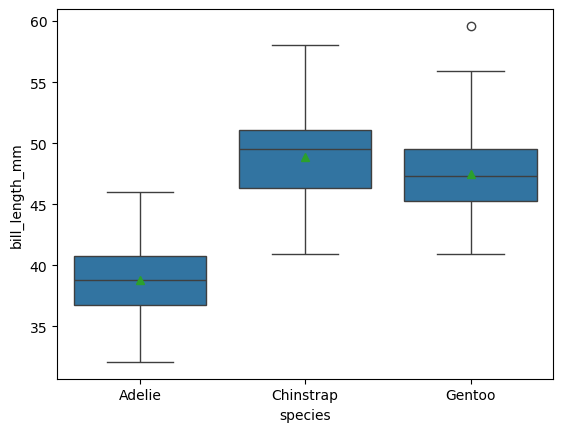

In [62]:
sns.boxplot(data = df, x = "species", y = "bill_length_mm", showmeans = True)
plt.show()

12. 펭귄 데이터셋에서 서식지(island)에 따라 체중(body_mass_g) 분포에 어떤 차이가 있는지 적절한 그래프로 분석하고, 그 결과를 간략하게 서술하시오

In [63]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


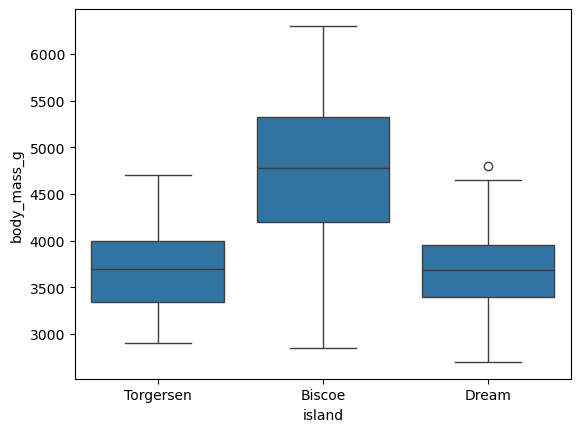

In [64]:
sns.boxplot(x = "island", y = "body_mass_g", data = df)
plt.show()

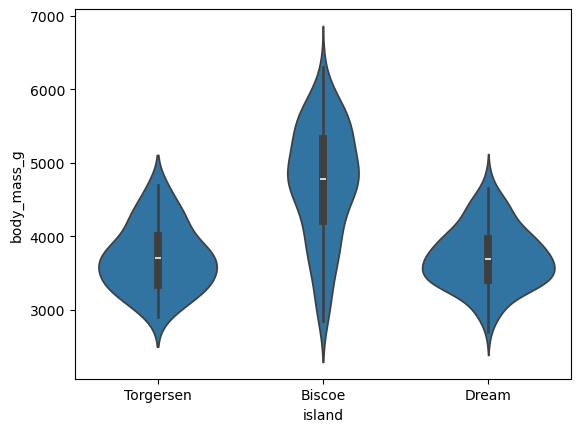

In [65]:
sns.violinplot(x = "island", y = "body_mass_g", data = df)
plt.show()

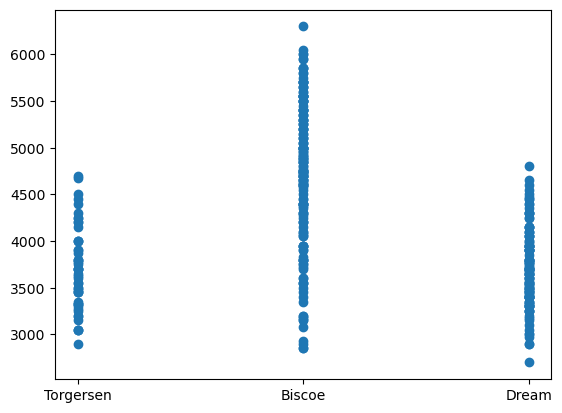

In [66]:
plt.scatter(df["island"], df["body_mass_g"])
plt.show()

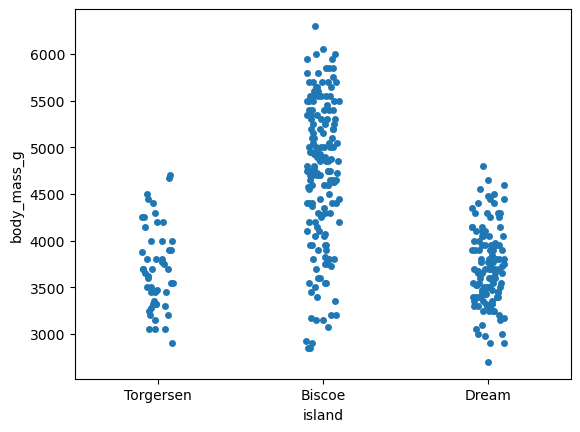

In [67]:
# strip plot
sns.stripplot(data = df, x = "island", y = "body_mass_g")
plt.show()

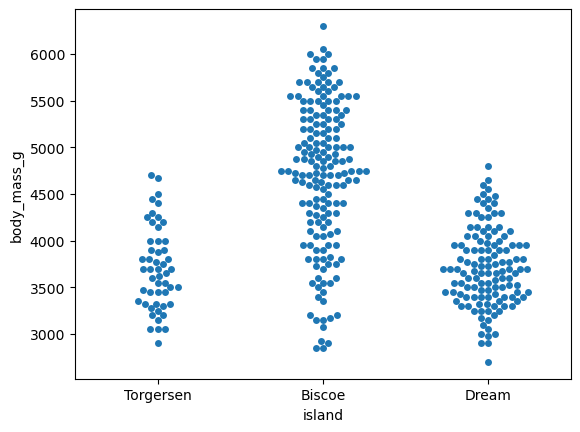

In [68]:
# swarm plot
sns.swarmplot(data = df, x = "island", y = "body_mass_g")
plt.show()

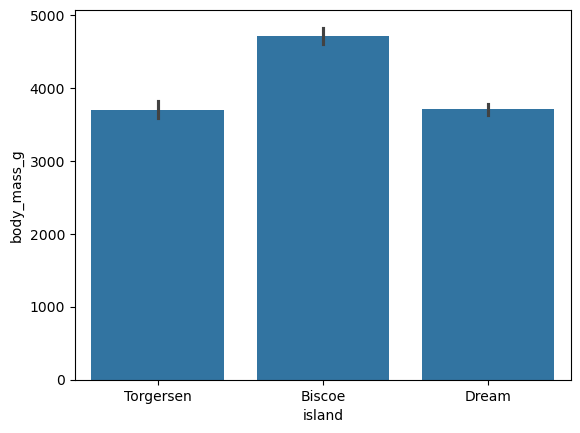

In [69]:
sns.barplot(data = df, x = "island", y = "body_mass_g")
plt.show()

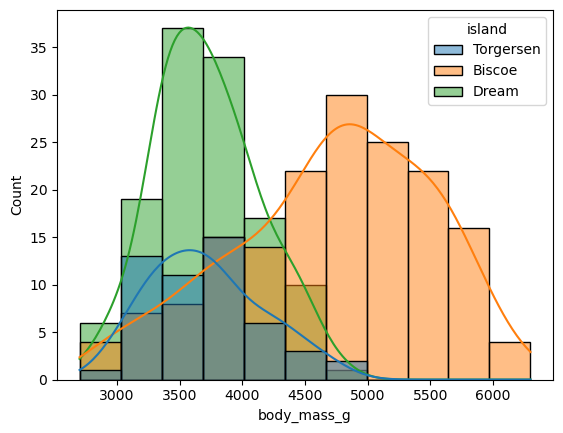

In [70]:
sns.histplot(df, x='body_mass_g', hue='island', kde=True)
plt.show()